In [1]:
from typing import TypedDict
from IPython.display import Image, display

from langgraph.graph import StateGraph, START, END

In [2]:
class State(TypedDict):
    customer_name: str
    my_age: int

In [3]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

In [4]:
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

In [5]:
builder.add_edge(START, 'node_1')
builder.add_edge('node_1', 'node_2')
builder.add_edge('node_2', 'node_3')
builder.add_edge('node_3', END)

In [6]:
agent = builder.compile()

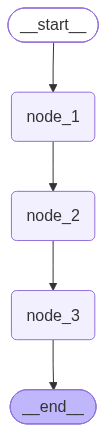

In [7]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [8]:
builder = StateGraph(State)

builder.add_edge(START, 'node_1')
builder.add_sequence([node_1, node_2, node_3])

agent = builder.compile()

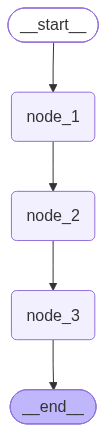

In [9]:
display(Image(agent.get_graph().draw_mermaid_png()))

conditional edge (routing)

In [ ]:
import random 
from typing import Literal

# edge solo leen estado, no modifican la memoria compartida de los edges, solo deciden a que nodo ir

def route_edge(state: State) -> Literal['node_2', 'node_3']:
    return random.choice(['node_2', 'node_3'])

In [11]:
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

In [14]:
builder.add_edge(START, 'node_1')
builder.add_conditional_edges('node_1', route_edge)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)

In [15]:
agent = builder.compile()

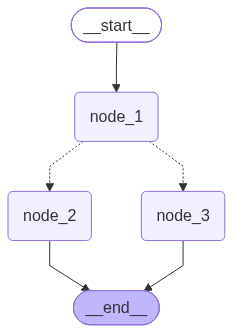

In [16]:
display(Image(agent.get_graph().draw_mermaid_png()))

In [19]:
# desde start

builder = StateGraph(State)
# builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_conditional_edges(START, route_edge)
builder.add_edge('node_2', END)
builder.add_edge('node_3', END)

agent = builder.compile()

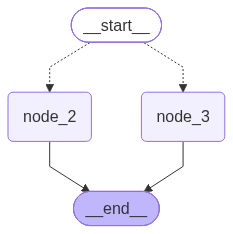

In [20]:
display(Image(agent.get_graph().draw_mermaid_png()))

START → clasificar → respuesta_directa → validar
      → corregir → validar → finalizar → END

In [21]:
from typing import Literal, TypedDict

from langgraph.graph import StateGraph, START, END


class State(TypedDict):
    consulta: str
    tipo: str
    respuesta: str
    valido: bool
    intentos: int
    estado: str


# Nodos: devuelven actualizaciones del estado.

def rechazar(state: State):
    return {"estado": "rechazado", "respuesta": "La consulta está vacía."}


def clasificar(state: State):
    # Regla didáctica: puedes reemplazarla por un clasificador o LLM.
    compleja = len(state["consulta"].split()) > 8
    return {"tipo": "compleja" if compleja else "simple"}


def respuesta_directa(state: State):
    return {"respuesta": "Respuesta breve a tu consulta."}


def investigar(state: State):
    # Aquí podrías consultar herramientas, una API o un buscador.
    return {"respuesta": "Información recopilada con fuentes verificadas."}


def generar(state: State):
    return {"respuesta": f"Respuesta detallada: {state['respuesta']}"}


def validar(state: State):
    # Validación simulada: requiere que la respuesta mencione fuentes.
    return {"valido": "fuentes" in state["respuesta"].lower()}


def corregir(state: State):
    return {
        "respuesta": state["respuesta"] + " Se agregaron fuentes verificadas.",
        "intentos": state["intentos"] + 1,
    }


def finalizar(state: State):
    return {"estado": "completado"}


def escalar(state: State):
    # Marca el caso como pendiente; no contacta a una persona.
    return {"estado": "requiere_revision"}


# Routers: leen el estado y eligen el siguiente nodo.

def route_edge(state: State) -> Literal["clasificar", "rechazar"]:
    return "clasificar" if state["consulta"].strip() else "rechazar"


def route_tipo(
    state: State,
) -> Literal["respuesta_directa", "investigar"]:
    return "investigar" if state["tipo"] == "compleja" else "respuesta_directa"


def route_validacion(
    state: State,
) -> Literal["finalizar", "corregir", "escalar"]:
    if state["valido"]:
        return "finalizar"

    if state["intentos"] < 2:
        return "corregir"

    return "escalar"


builder = StateGraph(State)

for name, node in [
    ("rechazar", rechazar),
    ("clasificar", clasificar),
    ("respuesta_directa", respuesta_directa),
    ("investigar", investigar),
    ("generar", generar),
    ("validar", validar),
    ("corregir", corregir),
    ("finalizar", finalizar),
    ("escalar", escalar),
]:
    builder.add_node(name, node)

# Primera decisión: entrada válida o rechazo.
builder.add_conditional_edges(START, route_edge)

# Segunda decisión: camino simple o complejo.
builder.add_conditional_edges("clasificar", route_tipo)

# Ambos caminos convergen en validar.
builder.add_edge("respuesta_directa", "validar")
builder.add_edge("investigar", "generar")
builder.add_edge("generar", "validar")

# Tercera decisión: finalizar, corregir o escalar.
builder.add_conditional_edges("validar", route_validacion)

# Ciclo de corrección.
builder.add_edge("corregir", "validar")

for node in ["rechazar", "finalizar", "escalar"]:
    builder.add_edge(node, END)

agent = builder.compile()

resultado = agent.invoke({
    "consulta": "¿Qué es LangGraph?",
    "tipo": "",
    "respuesta": "",
    "valido": False,
    "intentos": 0,
    "estado": "iniciado",
})

print(resultado)

{'consulta': '¿Qué es LangGraph?', 'tipo': 'simple', 'respuesta': 'Respuesta breve a tu consulta. Se agregaron fuentes verificadas.', 'valido': True, 'intentos': 1, 'estado': 'completado'}


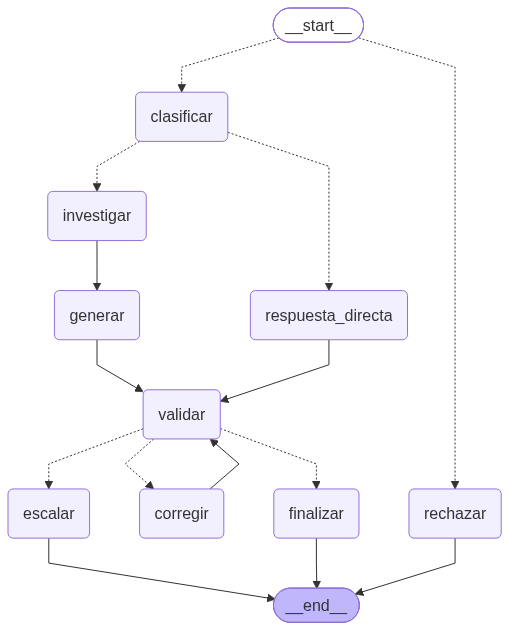

In [22]:
display(Image(agent.get_graph().draw_mermaid_png()))